In [1]:
import warnings
# Suppress all warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

In [2]:
ticker_symbol = "WMT"
# Fetch maximum available historical data
data = yf.download(ticker_symbol, period='5y', auto_adjust=True, multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [3]:
data

,Close,High,Low,Open,Volume
Date,,,,,
2020-12-02,46.801628,47.454588,46.493806,47.261811,23547000
2020-12-03,46.422295,46.727010,46.139346,46.727010,25725900
2020-12-04,46.301018,46.487578,45.887478,46.487578,20889300
2020-12-07,46.052269,46.325891,45.756884,46.161097,18479100
2020-12-08,46.468922,46.593296,45.763106,45.819072,20716500
...,...,...,...,...,...
2025-11-24,104.059998,106.269997,103.760002,105.360001,42519200
2025-11-25,107.000000,107.419998,104.230003,104.610001,20212900
2025-11-26,109.099998,109.589996,107.169998,107.199997,17783300


In [4]:
# Calculate log returns
data['Log_Return'] = data['Close'].pct_change().dropna()
# Drop the first row with NaN value
returns = data['Log_Return'].dropna()

print(f"Downloaded {len(returns)} data points for {ticker_symbol}")
print("\nSample Data (Returns):")
print(returns.head())
print(returns.tail())

Downloaded 1254 data points for WMT

Sample Data (Returns):
Date
2020-12-03   -0.008105
2020-12-04   -0.002612
2020-12-07   -0.005372
2020-12-08    0.009047
2020-12-09   -0.007896
Name: Log_Return, dtype: float64
Date
2025-11-24   -0.011964
2025-11-25    0.028253
2025-11-26    0.019626
2025-11-28    0.012924
2025-12-01    0.009230
Name: Log_Return, dtype: float64


/home/yurit/anaconda3/envs/wsq/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/yurit/anaconda3/envs/wsq/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/yurit/anaconda3/envs/wsq/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



AR(1) Model Summary:
                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                 1254
Model:                 ARIMA(1, 0, 0)   Log Likelihood                3657.055
Date:                Mon, 01 Dec 2025   AIC                          -7308.110
Time:                        19:44:53   BIC                          -7292.708
Sample:                             0   HQIC                         -7302.321
                               - 1254                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      1.957      0.050   -1.11e-06       0.002
ar.L1          0.0351      0.017      2.047      0.041       0.001       0.069
sigma2         0.0002   2.62e-

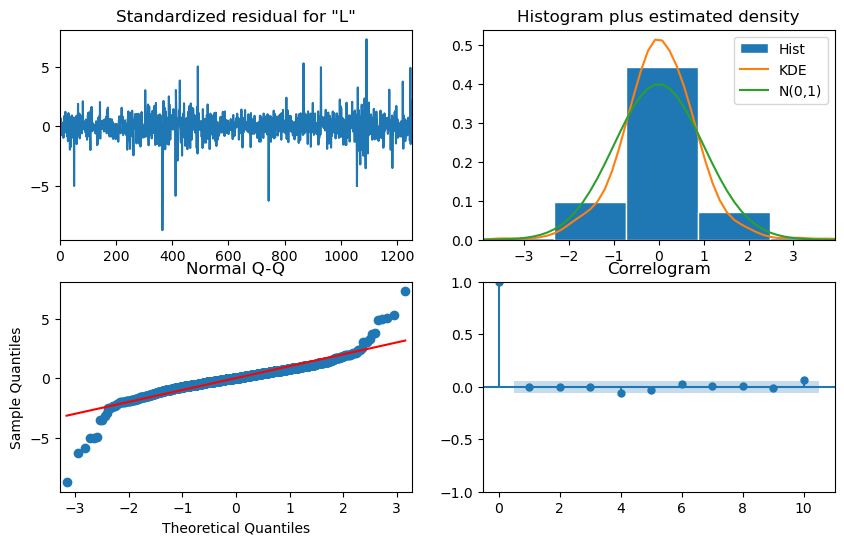

In [7]:
# 2. Fit an AR(1) model to the historical time-series
# For an AR(1) model, we use ARIMA with order=(p, d, q) = (1, 0, 0)
# 'p' is the AR order, 'd' is the integrated order (0 for stationary data like returns), 'q' is the MA order
try:
    model = ARIMA(returns, order=(1, 0, 0))
    results = model.fit()

    # 3. Print the model summary
    print("\nAR(1) Model Summary:")
    print(results.summary())

    # Extract and print the AR(1) coefficient (phi)
    # The coefficient for 'ar.L1' (lag 1 autoregressive term) is at index 0 in the 'ar.L1' parameter
    # Note: the exact name might vary slightly in the summary table
    phi_estimate = results.params['ar.L1']
    print(f"\nEstimated AR(1) coefficient (phi): {phi_estimate:.4f}")

    # Optional: Plot the residuals
    results.plot_diagnostics(figsize=(10, 6))
    plt.show()

except Exception as e:
    print(f"\nAn error occurred during model fitting: {e}")
    print("Ensure your time series data is appropriate for AR(1) modeling.")